In [5]:
# Colab cell 1
import pandas as pd

url = "https://raw.githubusercontent.com/Priyanshu-1729/Resume-Screening-using-Python/main/UpdatedResumeDataSet.csv"
df = pd.read_csv(url)

print(df.shape)
print(df['Category'].value_counts())
df.head()

(962, 2)
Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64


,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \nMay 2013 to May 2017 B.E ...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \n MCA YMCAUST, Faridabad..."


In [6]:
# Colab cell 2
import re
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_resume(text):
    text = re.sub(r'http\S+\s*', ' ', text)        # URLs
    text = re.sub(r'#\S+', '', text)                # hashtags
    text = re.sub(r'@\S+', '  ', text)               # mentions
    text = re.sub(r'[^\w\s]', ' ', text)             # special chars/punctuation
    text = re.sub(r'\d+', ' ', text)                 # numbers
    text = re.sub(r'\s+', ' ', text)                 # extra spaces
    text = text.lower().strip()                      # lowercase
    return text

def preprocess(text):
    text = clean_resume(text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

df['cleaned_resume'] = df['Resume'].apply(preprocess)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [7]:
# Colab cell 3
print("ORIGINAL (first 300 chars):")
print(df['Resume'][0][:300])
print("\n" + "="*80 + "\n")
print("CLEANED (first 300 chars):")
print(df['cleaned_resume'][0][:300])

ORIGINAL (first 300 chars):
Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language pr


CLEANED (first 300 chars):
skill programming language python panda numpy scipy scikit learn matplotlib sql java javascript jquery machine learning regression svm naã bayes knn random forest decision tree boosting technique cluster analysis word embedding sentiment analysis natural language processing dimensionality reduction 


In [8]:
# Colab cell 4
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

le = LabelEncoder()
df['Category_encoded'] = le.fit_transform(df['Category'])

tfidf = TfidfVectorizer(max_features=3000, sublinear_tf=True, stop_words='english')
X_tfidf = tfidf.fit_transform(df['cleaned_resume'])
y = df['Category_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Number of categories:", len(le.classes_))

Train shape: (769, 3000)
Test shape: (193, 3000)
Number of categories: 25


In [9]:
# Colab cell 5
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

svm = SVC(kernel='linear', class_weight='balanced', probability=True)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f"Accuracy: {acc:.4f}")
print(f"Precision (macro): {prec:.4f}")
print(f"Recall (macro): {rec:.4f}")
print(f"F1-Score (macro): {f1:.4f}")
print("\n" + classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

Accuracy: 0.9948
Precision (macro): 0.9933
Recall (macro): 0.9964
F1-Score (macro): 0.9945

                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       0.83      1.00      0.91         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       1.00      1.00      1.00         6
                       HR       1.00

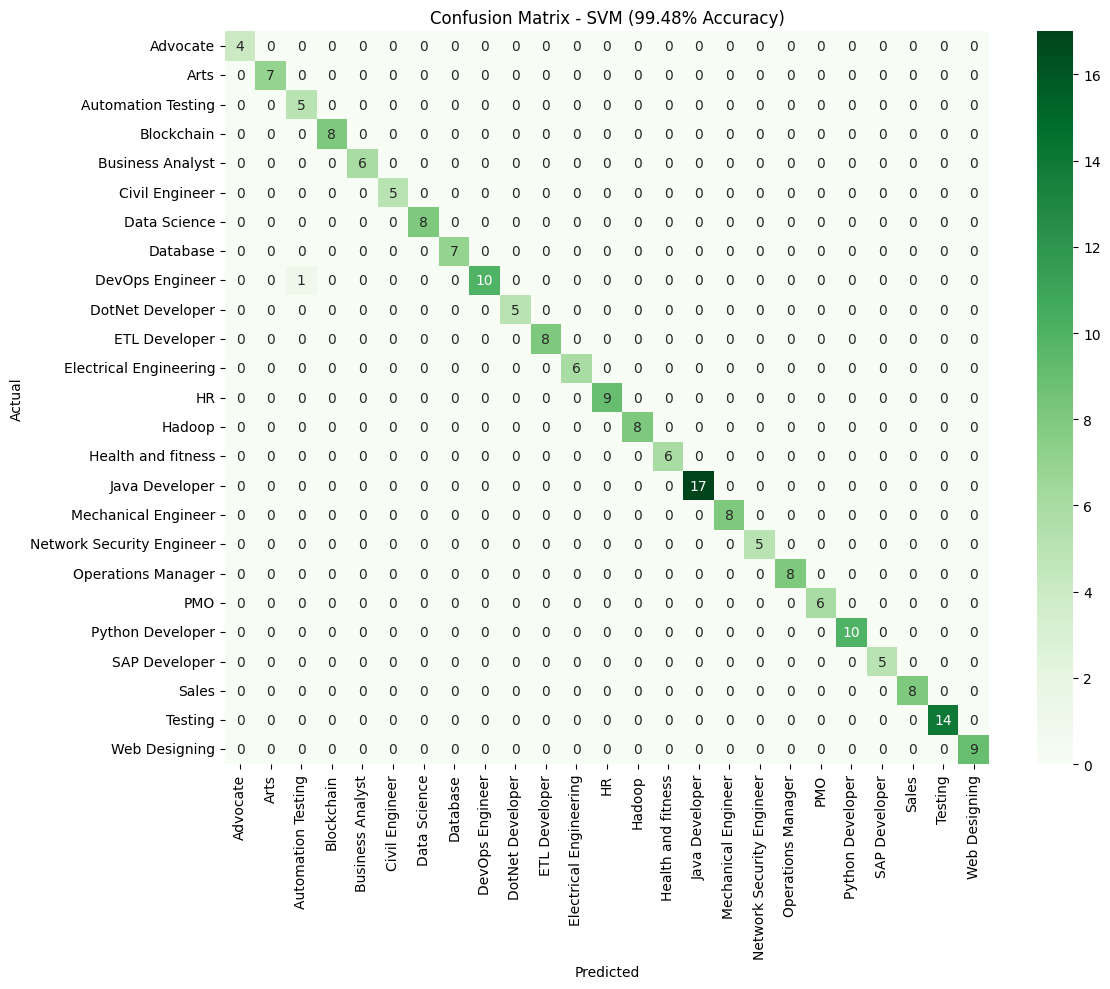

In [10]:
# Colab cell 6
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM (99.48% Accuracy)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_svm.png', dpi=300)
plt.show()

In [11]:
# Colab cell 7
import joblib

joblib.dump(svm, 'svm_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(le, 'label_encoder.pkl')

from google.colab import files
files.download('svm_model.pkl')
files.download('tfidf_vectorizer.pkl')
files.download('label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
# Colab cell 8
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 5000      # vocabulary size
MAX_LEN = 200          # max sequence length (resume ekකේ words count)

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['cleaned_resume'])

sequences = tokenizer.texts_to_sequences(df['cleaned_resume'])
X_padded = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print("Padded shape:", X_padded.shape)

Padded shape: (962, 200)


In [13]:
# Colab cell 9
from sklearn.model_selection import train_test_split

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_padded, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train_dl.shape)
print("Test shape:", X_test_dl.shape)

Train shape: (769, 200)
Test shape: (193, 200)


In [14]:
# Colab cell 10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.utils import to_categorical

num_classes = len(le.classes_)
y_train_cat = to_categorical(y_train_dl, num_classes=num_classes)
y_test_cat = to_categorical(y_test_dl, num_classes=num_classes)

model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    GRU(64, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(
    X_train_dl, y_train_cat,
    validation_data=(X_test_dl, y_test_cat),
    epochs=15,
    batch_size=16
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 0.1183 - loss: 3.1841 - val_accuracy: 0.2591 - val_loss: 3.0969
Epoch 2/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.2081 - loss: 3.0110 - val_accuracy: 0.2228 - val_loss: 2.8012
Epoch 3/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.2315 - loss: 2.6433 - val_accuracy: 0.3264 - val_loss: 2.3352
Epoch 4/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.3147 - loss: 2.3069 - val_accuracy: 0.3990 - val_loss: 2.0641
Epoch 5/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.3849 - loss: 2.0316 - val_accuracy: 0.4663 - val_loss: 1.8020
Epoch 6/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.4421 - loss: 1.8980 - val_accuracy: 0.5596 - val_loss: 1.6668
Epoch 7/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.4707 - loss: 1.7646 - val_accuracy: 0.5803 - val_loss: 1.5447
Epoch 8/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.5241 - loss: 1.6582 - val_accuracy: 0.5751 - v

In [15]:
# Colab cell 11
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np

y_pred_probs = model.predict(X_test_dl)
y_pred_gru = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_test_dl, y_pred_gru)
prec = precision_score(y_test_dl, y_pred_gru, average='macro', zero_division=0)
rec = recall_score(y_test_dl, y_pred_gru, average='macro', zero_division=0)
f1 = f1_score(y_test_dl, y_pred_gru, average='macro', zero_division=0)

print(f"Accuracy: {acc:.4f}")
print(f"Precision (macro): {prec:.4f}")
print(f"Recall (macro): {rec:.4f}")
print(f"F1-Score (macro): {f1:.4f}")
print("\n" + classification_report(y_test_dl, y_pred_gru, target_names=le.classes_, zero_division=0))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Accuracy: 0.7720
Precision (macro): 0.8768
Recall (macro): 0.7490
F1-Score (macro): 0.7693

                           precision    recall  f1-score   support

                 Advocate       0.00      0.00      0.00         4
                     Arts       1.00      0.71      0.83         7
       Automation Testing       1.00      1.00      1.00         5
               Blockchain       1.00      0.50      0.67         8
         Business Analyst       1.00      0.67      0.80         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      0.75      0.86         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      0.20      0.33         5
            ETL Developer       1.00      0.62      0.77         8
   Electrical Engineering       1.00      0.67      0.80         

In [16]:
# Colab cell 10b - FULL rebuild + rerun (paste this as one cell)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

num_classes = len(le.classes_)
y_train_cat = to_categorical(y_train_dl, num_classes=num_classes)
y_test_cat = to_categorical(y_test_dl, num_classes=num_classes)

model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    GRU(64, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_dl, y_train_cat,
    validation_data=(X_test_dl, y_test_cat),
    epochs=30,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.0897 - loss: 3.1840 - val_accuracy: 0.2332 - val_loss: 3.0924
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.1795 - loss: 3.0273 - val_accuracy: 0.2746 - val_loss: 2.9060
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.2211 - loss: 2.7538 - val_accuracy: 0.2591 - val_loss: 2.3901
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.2991 - loss: 2.3096 - val_accuracy: 0.4093 - val_loss: 2.0197
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.3940 - loss: 2.0100 - val_accuracy: 0.4663 - val_loss: 1.7858
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.4694 - loss: 1.8221 - val_accuracy: 0.5337 - val_loss: 1.6639
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.5059 - loss: 1.7164 - val_accuracy: 0.5648 - val_loss: 1.5311
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.5345 - loss: 1.6247 - val_accuracy: 0.6373 - val_loss: 1.

In [17]:
# Colab cell 11
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np

y_pred_probs = model.predict(X_test_dl)
y_pred_gru = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_test_dl, y_pred_gru)
prec = precision_score(y_test_dl, y_pred_gru, average='macro', zero_division=0)
rec = recall_score(y_test_dl, y_pred_gru, average='macro', zero_division=0)
f1 = f1_score(y_test_dl, y_pred_gru, average='macro', zero_division=0)

print(f"Accuracy: {acc:.4f}")
print(f"Precision (macro): {prec:.4f}")
print(f"Recall (macro): {rec:.4f}")
print(f"F1-Score (macro): {f1:.4f}")
print("\n" + classification_report(y_test_dl, y_pred_gru, target_names=le.classes_, zero_division=0))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Accuracy: 0.9896
Precision (macro): 0.9929
Recall (macro): 0.9864
F1-Score (macro): 0.9886

                           precision    recall  f1-score   support

                 Advocate       1.00      0.75      0.86         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       1.00      1.00      1.00         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       1.00      1.00      1.00         

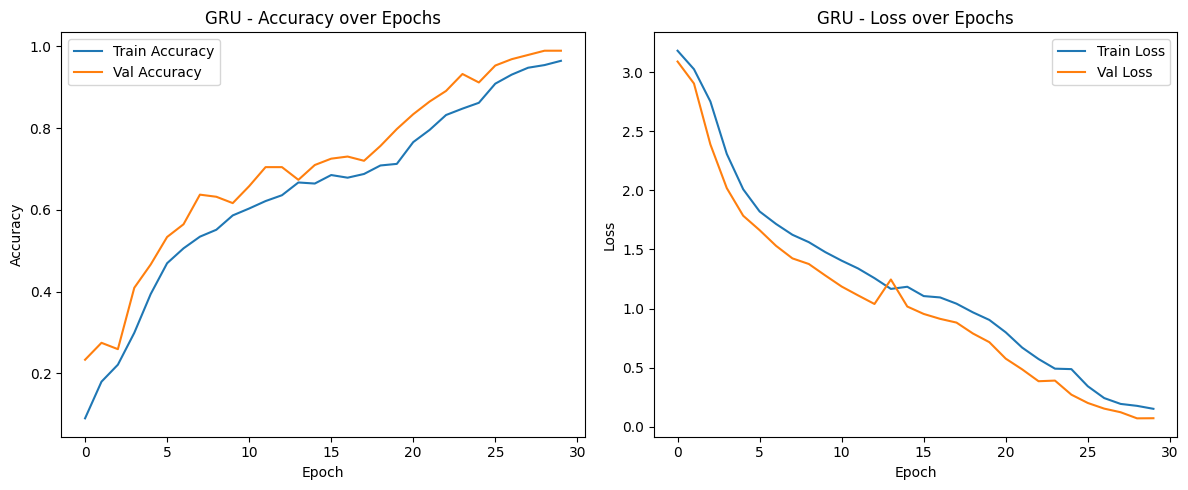

In [18]:
# Colab cell 12 - training history plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('GRU - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('GRU - Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('gru_training_curves.png', dpi=150)
plt.show()

In [19]:
# Colab cell 13
import joblib

model.save('gru_model.h5')                       # Keras model save
joblib.dump(tokenizer, 'gru_tokenizer.pkl')       # Tokenizer save
joblib.dump(le, 'gru_label_encoder.pkl')          # Label encoder save

from google.colab import files
files.download('gru_model.h5')
files.download('gru_tokenizer.pkl')
files.download('gru_label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

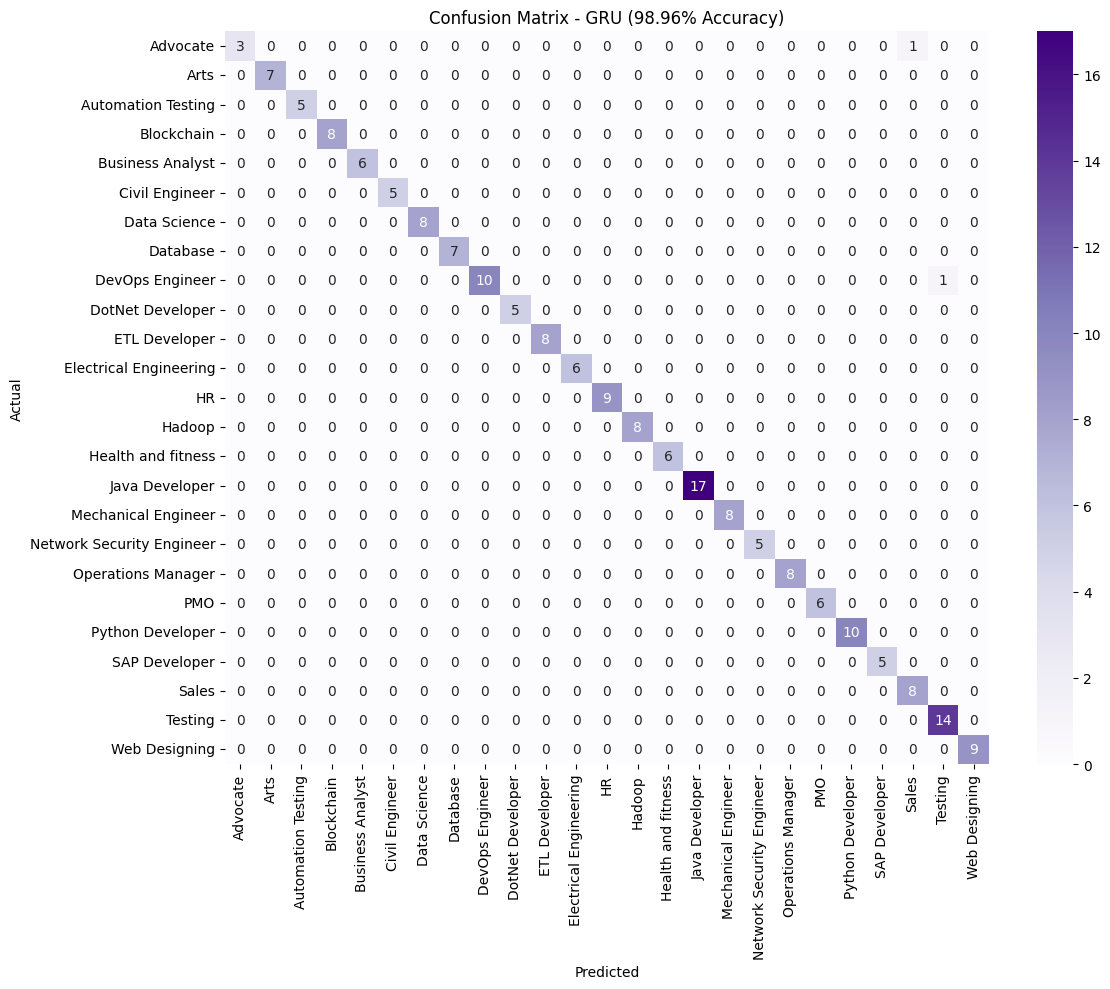

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_dl, y_pred_gru)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - GRU (98.96% Accuracy)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_gru.png', dpi=150)
plt.show()
files.download('confusion_matrix_gru.png')

In [23]:
from google.colab import files

files.download('confusion_matrix_svm.png')
files.download('gru_training_curves.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>